# **花卉图像分类**

## 注意事项

1、本案例使用AI框架：**MindSpore1.1.1**。

2、本案例最低硬件规格要求：**GPU**。

3、切换硬件规格的方法：如需切换硬件规格，您可以在本页面右边的工作区进行切换。

4、运行代码方法：点击本页面顶部菜单栏的三角形运行按钮或按Ctrl + Enter键运行每个方块中的代码。

5、JupyterLab的详细用法：[请参考《ModelAtrs JupyterLab使用指导》](https://bbs.huaweicloud.com/forum/thread-97603-1-1.html)

6、Kernel Restarting、Kernel died及其他常见问题的解决办法： [请参考《ModelAtrs JupyterLab常见问题解决办法》](https://bbs.huaweicloud.com/forum/thread-98681-1-1.html)

## 案例内容介绍
随着电子技术的迅速发展,人们使用便携数码设备(如手机、相机等)获取花卉图像越来越方便,如何自动识别花卉种类受到了广泛的关注。由于花卉所处背景的复杂性,以及花卉自身的类间相似性和类内多样性,利用传统的手工提取特征进行图像分类的方法,并不能很好地解决花卉图像分类这一问题。   



按照体系结构划分，整个实验的体系结构可以划分为三部分，分别为模型训练、模型保存和模型推理，如下图所示。各层侧重点各不相同。
- 训练层运行在安装有MindSpore框架的服务器，最好配置计算加速卡。
- 推断层运行于开发环境，能够支持卷积神经网络的加速。
- 展示层运行于客户端应用程序，能够完成图像选择并实时显示推断层的计算结果。

各层之间存在单向依赖关系。推断层需要的网络模型由训练层提供，并根据需要进行必要的格式转换或加速重构。相应的，展示层要显示的元数据需要由推断层计算得到。
![cnn](https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com/course/hwc_edu/python_module_framework/datasets/mindspore_data/flower/cnn.png)
本实验基于卷积神经网络实现的花卉识别实验与传统图像分类方法不同,卷积神经网络无需人工提取特征,可以根据输入图像,自动学习包含丰富语义信息的特征,得到更为全面的花卉图像特征描述,可以很好地表达图像的不同类别信息。

## 实验目标

该实验将用户在客户端选取的花卉图像作为输入，运行部署在华为云ModelArts上的花卉识别模型，实时返回识别结果作为输出结果并显示给用户。

## 实验步骤

### 1. 导入实验环境

导入相应的模块

In [1]:
#easydict模块用于以属性的方式访问字典的值
from easydict import EasyDict as edict
#glob模块主要用于查找符合特定规则的文件路径名，类似使用windows下的文件搜索
import glob
#os模块主要用于处理文件和目录
import os

import numpy as np
import matplotlib.pyplot as plt

import mindspore
#导入mindspore框架数据集
import mindspore.dataset as ds
#vision.c_transforms模块是处理图像增强的高性能模块，用于数据增强图像数据改进训练模型。
import mindspore.dataset.vision.c_transforms as CV
#c_transforms模块提供常用操作，包括OneHotOp和TypeCast
import mindspore.dataset.transforms.c_transforms as C
from mindspore.common import dtype as mstype
from mindspore import context
#导入模块用于初始化截断正态分布
from mindspore.common.initializer import TruncatedNormal
from mindspore import nn
from mindspore.train import Model
from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor, TimeMonitor
from mindspore.train.serialization import load_checkpoint, load_param_into_net
from mindspore import Tensor
# 设置MindSpore的执行模式和设备
context.set_context(mode=context.GRAPH_MODE, device_target="GPU")  # 支持GPU / Ascend

[WARNING] ME(13683:140041943766848,MainProcess):2021-05-24-19:58:29.952.373 [mindspore/ops/operations/array_ops.py:2302] WARN_DEPRECATED: The usage of Pack is deprecated. Please use Stack.


定义变量

In [2]:
cfg = edict({
    'data_path': './datasets',
    'data_size':3670,
    'image_width': 100,  # 图片宽度
    'image_height': 100,  # 图片高度
    'batch_size': 32,
    'channel': 3,  # 图片通道数
    'num_class':5,  # 分类类别
    'weight_decay': 0.01,
    'lr':0.0001,  # 学习率
    'dropout_ratio': 0.5,
    'epoch_size': 400,  # 训练次数
    'sigma':0.01,
    
    'save_checkpoint_steps': 1,  # 多少步保存一次模型
    'keep_checkpoint_max': 1,  # 最多保存多少个模型
    'output_directory': './model',  # 保存模型路径
    'output_prefix': "checkpoint_classification"  # 保存模型文件名字
})

### 2. 数据集获取与预处理

获取数据集，此处不用修改路径

In [3]:
import moxing as mox
datasets = os.path.join(cfg.data_path, 'flower_photos.zip')
if not os.path.exists(cfg.data_path):
    os.makedirs(cfg.data_path)
    mox.file.copy('obs://modelarts-labs-bj4/course/hwc_edu/python_module_framework/datasets/mindspore_data/flower/flower_photos.zip', datasets)
    os.system('cd %s; unzip flower_photos.zip' % (cfg.data_path))

INFO:root:Using MoXing-v1.17.3-43fbf97f
INFO:root:Using OBS-Python-SDK-3.20.7


数据预处理

In [4]:
#从目录中读取图像的源数据集。
de_dataset = ds.ImageFolderDataset(os.path.join(cfg.data_path, "flower_photos"),
                                   class_indexing={'daisy':0,'dandelion':1,'roses':2,'sunflowers':3,'tulips':4})
#解码前将输入图像裁剪成任意大小和宽高比。
transform_img = CV.RandomCropDecodeResize([cfg.image_width,cfg.image_height], scale=(0.08, 1.0), ratio=(0.75, 1.333))  #改变尺寸
#转换输入图像；形状（H, W, C）为形状（C, H, W）。
hwc2chw_op = CV.HWC2CHW()
#转换为给定MindSpore数据类型的Tensor操作。
type_cast_op = C.TypeCast(mstype.float32)
#将操作中的每个操作应用到此数据集。
de_dataset = de_dataset.map(input_columns="image", num_parallel_workers=8, operations=transform_img)
de_dataset = de_dataset.map(input_columns="image", operations=hwc2chw_op, num_parallel_workers=8)
de_dataset = de_dataset.map(input_columns="image", operations=type_cast_op, num_parallel_workers=8)
de_dataset = de_dataset.shuffle(buffer_size=cfg.data_size)

划分训练集与测试集
- 按照8:2的比列将数据划分为训练数据集和测试数据集
- 对训练数据和测试数据分批次（batch）

[WARNING] ME(13683:140041943766848,MainProcess):2021-05-24-19:58:42.135.051 [mindspore/dataset/engine/datasets.py:855] Dataset is shuffled before split.


训练数据集数量： 2912
测试数据集数量： 704
通道数/图像长/宽： (3, 100, 100)
一张图像的标签样式： 4


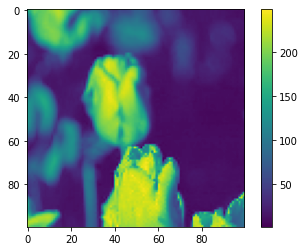

In [5]:
#划分训练集测试集
(de_train,de_test)=de_dataset.split([0.8,0.2])
#设置每个批处理的行数
#drop_remainder确定是否删除最后一个可能不完整的批（default=False）。
#如果为True，并且如果可用于生成最后一个批的batch_size行小于batch_size行，则这些行将被删除，并且不会传播到子节点。
de_train=de_train.batch(cfg.batch_size, drop_remainder=True)
#重复此数据集计数次数。
de_test=de_test.batch(cfg.batch_size, drop_remainder=True)
print('训练数据集数量：',de_train.get_dataset_size()*cfg.batch_size)#get_dataset_size()获取批处理的大小。
print('测试数据集数量：',de_test.get_dataset_size()*cfg.batch_size)

data_next=de_dataset.create_dict_iterator(output_numpy=True).__next__()
print('通道数/图像长/宽：', data_next['image'].shape)
print('一张图像的标签样式：', data_next['label'])  # 一共5类，用0-4的数字表达类别。

plt.figure()
plt.imshow(data_next['image'][0,...])
plt.colorbar()
plt.grid(False)
plt.show()

### 3. 构建CNN图像识别模型
花卉图像数据集准备完成，接下来我们就需要构建训练模型，本实验采用的是CNN神经网络算法。

定义图像识别模型

In [6]:
# 定义CNN图像识别网络
class Identification_Net(nn.Cell):
    def __init__(self, num_class=5,channel=3,dropout_ratio=0.5,trun_sigma=0.01):  # 一共分五类，图片通道数是3
        super(Identification_Net, self).__init__()
        self.num_class = num_class
        self.channel = channel
        self.dropout_ratio = dropout_ratio
        #设置卷积层
        self.conv1 = nn.Conv2d(self.channel, 32,
                               kernel_size=5, stride=1, padding=0,
                               has_bias=True, pad_mode="same",
                               weight_init=TruncatedNormal(sigma=trun_sigma),bias_init='zeros')
        #设置ReLU激活函数
        self.relu = nn.ReLU()
        #设置最大池化层
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2,pad_mode="valid")
        self.conv2 = nn.Conv2d(32, 64,
                               kernel_size=5, stride=1, padding=0,
                               has_bias=True, pad_mode="same",
                               weight_init=TruncatedNormal(sigma=trun_sigma),bias_init='zeros')
        self.conv3 = nn.Conv2d(64, 128,
                               kernel_size=3, stride=1, padding=0,
                               has_bias=True, pad_mode="same",
                               weight_init=TruncatedNormal(sigma=trun_sigma),bias_init='zeros')
        self.conv4 = nn.Conv2d(128, 128,
                               kernel_size=3, stride=1, padding=0,
                               has_bias=True, pad_mode="same",
                               weight_init=TruncatedNormal(sigma=trun_sigma), bias_init='zeros')
        self.flatten = nn.Flatten()
        self.fc1 = nn.Dense(6*6*128, 1024,weight_init =TruncatedNormal(sigma=trun_sigma),bias_init = 0.1)
        self.dropout = nn.Dropout(self.dropout_ratio)
        self.fc2 = nn.Dense(1024, 512, weight_init=TruncatedNormal(sigma=trun_sigma), bias_init=0.1)
        self.fc3 = nn.Dense(512, self.num_class, weight_init=TruncatedNormal(sigma=trun_sigma), bias_init=0.1)
    #构建模型
    def construct(self, x):
        x = self.conv1(x)
        #print(x.shape)
        x = self.relu(x)
        x = self.max_pool2d(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.max_pool2d(x)
        x = self.conv3(x)
        x = self.max_pool2d(x)
        x = self.conv4(x)
        x = self.max_pool2d(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        #print(x.shape)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

模型训练

In [7]:
net=Identification_Net(num_class=cfg.num_class, channel=cfg.channel, dropout_ratio=cfg.dropout_ratio)
#计算softmax交叉熵。
net_loss = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
#opt
fc_weight_params = list(filter(lambda x: 'fc' in x.name and 'weight' in x.name, net.trainable_params()))
other_params=list(filter(lambda x: 'fc' not in x.name or 'weight' not in x.name, net.trainable_params()))
group_params = [{'params': fc_weight_params, 'weight_decay': cfg.weight_decay},
                {'params': other_params},
                {'order_params': net.trainable_params()}]
#设置Adam优化器
net_opt = nn.Adam(group_params, learning_rate=cfg.lr, weight_decay=0.0)
#net_opt = nn.Adam(params=net.trainable_params(), learning_rate=cfg.lr, weight_decay=0.1)

model = Model(net, loss_fn=net_loss, optimizer=net_opt, metrics={"acc"})
loss_cb = LossMonitor(per_print_times=de_train.get_dataset_size()*10)
config_ck = CheckpointConfig(save_checkpoint_steps=cfg.save_checkpoint_steps,
                             keep_checkpoint_max=cfg.keep_checkpoint_max)

if not os.path.exists(cfg.output_directory):
    os.makedirs(cfg.output_directory)
ckpoint_cb = ModelCheckpoint(prefix=cfg.output_prefix, directory=cfg.output_directory, config=config_ck)
print("============== Starting Training ==============")
model.train(cfg.epoch_size, de_train, callbacks=[loss_cb, ckpoint_cb], dataset_sink_mode=True)

# 使用测试集评估模型，打印总体准确率
metric = model.eval(de_test)
print(metric)

============== Starting Training ==============
epoch: 10 step: 91, loss is 0.82701194
epoch: 20 step: 91, loss is 0.721948
epoch: 30 step: 91, loss is 0.47575086
epoch: 40 step: 91, loss is 0.7572126
epoch: 50 step: 91, loss is 0.46376267
epoch: 60 step: 91, loss is 0.81703806
epoch: 70 step: 91, loss is 0.7614599
epoch: 80 step: 91, loss is 0.532353
epoch: 90 step: 91, loss is 0.44781676
epoch: 100 step: 91, loss is 0.55134463
epoch: 110 step: 91, loss is 0.2794654
epoch: 120 step: 91, loss is 0.67139995
epoch: 130 step: 91, loss is 0.51088995
epoch: 140 step: 91, loss is 0.2964428
epoch: 150 step: 91, loss is 0.5953993
epoch: 160 step: 91, loss is 0.53314596
epoch: 170 step: 91, loss is 0.391652
epoch: 180 step: 91, loss is 0.31997633
epoch: 190 step: 91, loss is 0.44660708
epoch: 200 step: 91, loss is 0.5062503
epoch: 210 step: 91, loss is 0.16881546
epoch: 220 step: 91, loss is 0.3298071
epoch: 230 step: 91, loss is 0.25709185
epoch: 240 step: 91, loss is 0.29192424
epoch: 250 ste

### 4. 图像分类模型验证
- 验证之前训练出来的模型的性能。
- 掌握利图像识别模型验证方法。

加载训练模型

In [8]:
#加载模型
import os
CKPT = os.path.join(cfg.output_directory,cfg.output_prefix+'-'+str(cfg.epoch_size)+'_'+str(de_train.get_dataset_size())+'.ckpt')
net = Identification_Net(num_class=cfg.num_class, channel=cfg.channel, dropout_ratio=cfg.dropout_ratio)
load_checkpoint(CKPT, net=net)
model = Model(net)

验证推理

In [9]:
# 预测
class_names = {0:'daisy',1:'dandelion',2:'roses',3:'sunflowers',4:'tulips'}
test_ = next(de_test.create_dict_iterator())
test = Tensor(test_['image'], mindspore.float32)
predictions = model.predict(test)
predictions = predictions.asnumpy()
true_label = test_['label'].asnumpy()

#显示预测结果
for i in range(10):
    p_np = predictions[i, :]
    pre_label = np.argmax(p_np)
    print('第' + str(i) + '个sample预测结果：', class_names[pre_label], '   真实结果：', class_names[true_label[i]])

第0个sample预测结果： tulips    真实结果： tulips
第1个sample预测结果： dandelion    真实结果： tulips
第2个sample预测结果： roses    真实结果： roses
第3个sample预测结果： dandelion    真实结果： dandelion
第4个sample预测结果： tulips    真实结果： tulips
第5个sample预测结果： daisy    真实结果： daisy
第6个sample预测结果： roses    真实结果： roses
第7个sample预测结果： daisy    真实结果： daisy
第8个sample预测结果： dandelion    真实结果： dandelion
第9个sample预测结果： roses    真实结果： daisy


从上面预测结果可以看出整体模型的预测精度还是不错的，10个样本中有8个预测正确。可以通过调整训练时长和超参数得到更优的模型。

## 实验总结
本章提供了一个基于华为ModelArts平台的图像识别实验。该实验演示了如何利用华为云ModelArts完成图像识别任务。

本章对实验实验做了详尽的剖析。阐明了整个实验功能、结构与流程是如何设计的，详细解释了如何解析数据、如何构建深度学习模型、如何保存模型等内容。部署后的实验多个类别图片下进行测试，结果表明实验实验具有较快的推断速度和较好的识别性能。

读者可以在该实验实验的基础上开发更有针对性的应用实验。

## 创新设计
基于本实验的描述，请使用数据集CIFAR10完成图片识别任务并搭建一套自定义的图片识别实验。